In [36]:
import os 
import sys

import numpy as np
import matplotlib.pyplot as plt
import cv2 

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

## **Dataset visualisation**
This notebook is used to visualisation some examples of sonar odometry dataset. 


1. **Setup**
___

In [37]:
SEQ_ID = 1 # number of sequence
seq_start = 0 # amount od sequence samples to show - beginning (0.0 - 1.0)
seq_stop = 1 # amount od sequence samples to show - end (0.0 - 1.0)

os.environ['DISPLAY'] = ':23'

In [38]:
# Print dataset info 
from src.compress import get_size

seq_num = 0
frames_per_seq = []
seq_name = []
for seq in sorted(os.listdir(os.path.join(root_dir, 'data'))):
    seq_num += 1
    frames_per_seq_curr = 0 
    for sample in os.listdir(os.path.join(root_dir, 'data', seq, 'fls')):
        frames_per_seq_curr += 1
    frames_per_seq.append(frames_per_seq_curr)
    seq_name.append(seq)

total_size = get_size(os.path.join(root_dir, 'data'))

total_size_GB = total_size/(1024*1024*1024)

print('Dataset statistics:')
print('-'*60)
print(f'Sequences number: {seq_num}')
print(f'Total samples: {sum(frames_per_seq)}')
print(f'Total size: {total_size_GB} GB ({total_size } bytes)')
print('-'*60)
for idx, seg in enumerate(frames_per_seq):
    print(f'- seq_{seq_name[idx]}: {frames_per_seq[idx]} samples')
print('-'*60)


Dataset statistics:
------------------------------------------------------------
Sequences number: 3
Total samples: 3500
Total size: 0.24526300746947527 GB (263349149 bytes)
------------------------------------------------------------
- seq_seq_0: 1000 samples
- seq_seq_1: 500 samples
- seq_seq_2: 2000 samples
------------------------------------------------------------


2. **Trajectory**
___

In [39]:
trajectory_pth = os.path.join(root_dir, f'data/seq_{SEQ_ID}/sequence.csv') # path to csv file with trajectory data

data = np.loadtxt(trajectory_pth, delimiter = ',', skiprows=1) # read data from csv 

samples_num = data.shape[0] # get number of samples
print(f'Imported {data.shape[0]} samples with {data.shape[1]} categories.')

from src.utils import data_headers as h # headers of csv file
first_sample = int(seq_start*samples_num)
last_sample =  int(seq_stop*samples_num)
samples_num_visu = last_sample - first_sample

print('Visualisation parameters:')
print(f'   - Samples amount: {samples_num_visu}')
print(f"   - Time: {data[samples_num_visu - 1, h['t']]} [s]")

Imported 500 samples with 23 categories.
Visualisation parameters:
   - Samples amount: 500
   - Time: 490.664 [s]


2.1. **Trajectory in XY plane.**

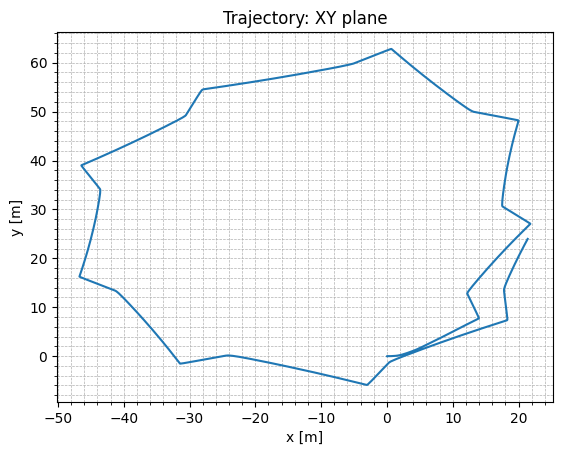

In [40]:
plt.figure()
plt.plot(data[first_sample:last_sample, h['pos_x']], data[first_sample:last_sample, h['pos_y']])
plt.title('Trajectory: XY plane')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

2.2. **Depth in time.**

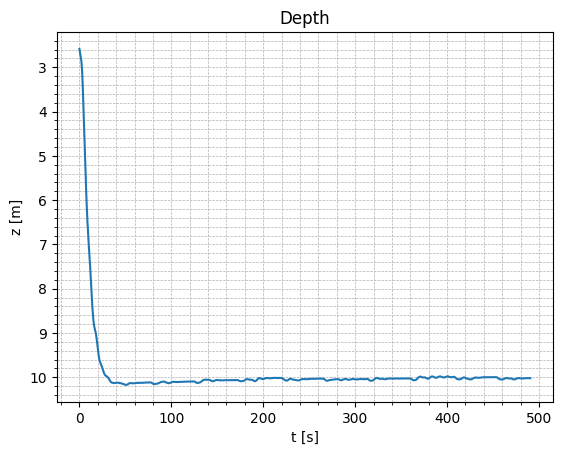

In [41]:
plt.figure()
plt.plot(data[first_sample:last_sample, h['t']], data[first_sample:last_sample, h['pos_z']])
plt.title('Depth')
plt.xlabel('t [s]')
plt.ylabel('z [m]')
plt.gca().invert_yaxis()
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

2.3. **X and Y in time**

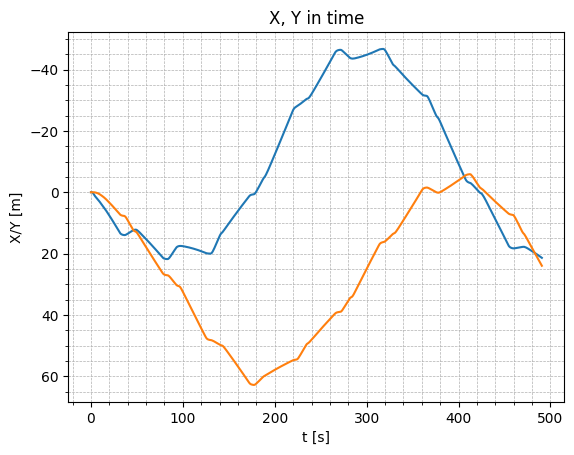

In [42]:
plt.figure()
plt.plot(data[first_sample:last_sample, h['t']], data[first_sample:last_sample, h['pos_x']])
plt.plot(data[first_sample:last_sample, h['t']], data[first_sample:last_sample, h['pos_y']])
plt.title('X, Y in time')
plt.xlabel('t [s]')
plt.ylabel('X/Y [m]')
plt.gca().invert_yaxis()
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

3. **Sequence visualisation**

Run following cells to play sequence.

Press `ESC` to quit video.

In [43]:
FPS = 2 

In [44]:
from src.utils import polar2cartesian
from src.noises_numpy import addSpeckleNoise, energyLoss, addBandReflects

In [45]:
sequence_dir = os.path.join(root_dir, f'data/seq_{SEQ_ID}/fls')

frames = sorted(
    os.listdir(sequence_dir),
    key=lambda x: int(os.path.splitext(x)[0])
)



In [46]:
for idx, f in enumerate(frames):
    img_pth = os.path.join(sequence_dir, f)
    I = cv2.imread(img_pth)
    I = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)

    # add noise
    I = addBandReflects(I, omega1 = 0.03, omega2 = 0.07, gain = 0.02)
    I = energyLoss(I, alpha = 0.02)
    I = addSpeckleNoise(I, m_min = 30, m_max = 100, sigma = 0.25, beam_width=2.0)
    I = I.astype(np.uint8)

    # convert to cartesian
    I_cart = polar2cartesian(I, r_min = 0.5, r_max = 30.0, theta_min = -65*np.pi/180, theta_max = 65*np.pi/180, out_shape = None)
    I_cart = cv2.resize(I_cart, None, fx=0.5, fy=0.5)

    I_cart = cv2.applyColorMap(I_cart, cv2.COLORMAP_HOT)
    
    txt = f'Frame: {idx}/{samples_num_visu}'
    cv2.putText(I_cart, txt, (20, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    cv2.imshow('Cartesian', I_cart)

    if cv2.waitKey(int(1000/FPS)) & 0xFF == 27:  
        break

cv2.destroyAllWindows()